<a href="https://colab.research.google.com/github/tnc-br/ddf-isoscapes/blob/npr-working/probability-assignment-evals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Isoscape Fraud Detection Evals

Notebook Purpose: Eval isoscape generation methods for our paper

Task: Compute the precision and recall of fraud detection by probability assignment (e.g. assignR), with calibration performed by thresholding.

# Setup

## Fetch Dependencies

In [1]:
!pip install rasterio fiona pykrige

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.3/17.3 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 979.6/979.6 kB 12.0 MB/s eta 0:00:00


## Import libraries required

In [2]:
import importlib
from datetime import datetime
import sys
import os

In [3]:
!if [ ! -d "/content/ddf_common_stub" ] ; then git clone -b test https://github.com/tnc-br/ddf_common_stub.git; fi
sys.path.append("/content/ddf_common_stub/")
import ddfimport
ddfimport.ddf_import_common()

Cloning into 'ddf_common_stub'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (18/18), done.
remote: Total 18 (delta 7), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 7.36 KiB | 1.47 MiB/s, done.
Resolving deltas: 100% (7/7), done.
executing checkout_branch ...
b''
main branch checked out as readonly. You may now use ddf_common imports


In [4]:
import train_variational_inference_model as tvim
import raster
import eeddf
import dataset
import fiona
import rasterio.mask
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount(raster.GDRIVE_BASE)

# Leave test_environment=True. Experiments must be done in test.
eeddf.initialize_ddf(test_environment=True)

Mounted at /content/gdrive


In [5]:
# Patch https://github.com/tnc-br/ddf_common/issues/72 here
import evaluation
importlib.reload(evaluation)
importlib.reload(tvim)
import evaluation

# Repartition

In [6]:
repartition = False # @param{type: "boolean"}

import pandas as pd
import numpy as np

def split_data(df, train_size=0.8, val_size=0.1, test_size=0.1, random_state=None):
  if train_size + val_size + test_size != 1:
    raise ValueError("Train, validation, and test sizes must add up to 1.")

  randomized = df.sample(frac=1, random_state=random_state)
  val_idx = int(len(randomized)*train_size)
  test_idx = int((len(randomized) - val_idx) * (val_size / (val_size+test_size)) + val_idx)

  train = randomized[:val_idx]
  val = randomized[val_idx:test_idx]
  test = randomized[test_idx:]

  if len(train) + len(val) + len(test) != len(df):
    raise Exception("Logic error")

  return train, val, test

if repartition:
    csv_file = pd.read_csv(raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/12_16_filtered_train_random_grouped_no_nans_recombined.csv')
    train, val, test = split_data(csv_file, 0.8, 0.1, 0.1, np.random.RandomState(42))
    train.to_csv(raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/12_16_filtered_train_random_iid_nonan.csv', index=False)
    val.to_csv(raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/12_16_filtered_validation_random_iid_nonan.csv', index=False)
    test.to_csv(raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE + 'canonical/12_16_filtered_test_random_iid_nonan.csv', index=False)

# Data configuration

In [7]:
# REQUIREMENTS:

# 1) Column names must match features_to_standardize, features_to_passthrough
# 2) Label columns in particular must match var_label and mean_label.
#
# If you used the data ingestion notebook (ingestion.ipynb) then this
# should be set up for you already.

# TRAINING FILE PARAMS
DATABASE_DIR = raster.GDRIVE_BASE + raster.SAMPLE_DATA_BASE
TRAINING_SET_FILE = 'canonical/12_16_filtered_train_random_iid_nonan.csv' #@param
VALIDATION_SET_FILE = 'canonical/12_16_filtered_validation_random_iid_nonan.csv' #@param
TEST_SET_FILE = 'canonical/12_16_filtered_test_random_iid_nonan.csv' #@param

# EVAL FILE PARAMS
EVAL_DATASET = 'canonical/12_16_filtered_test_random_iid_nonan.csv' #@param
#ORIGINAL_DATASET = 'canonical/2023_07_27_Results_google_utf8_latlonadded.csv' #@param
ORIGINAL_DATASET = 'canonical/12_16_ungrouped.csv' #@param


fileset = {
    'TRAIN' : os.path.join(DATABASE_DIR, TRAINING_SET_FILE),
    'TEST' : os.path.join(DATABASE_DIR, TEST_SET_FILE),
    'VALIDATION' : os.path.join(DATABASE_DIR, VALIDATION_SET_FILE),
    'EVAL' : os.path.join(DATABASE_DIR, EVAL_DATASET),
    'ORIGINAL' : os.path.join(DATABASE_DIR, ORIGINAL_DATASET)
}

def prepare_dataset(params: tvim.VIModelTrainingParams, files: dict) -> dataset.ScaledPartitions:
  # Prepared columns not in the original input-- these are engineered features
  # that we believe include strong signals, stored as geotiffs
  potentially_extra_columns = [
      "brisoscape_mean_ISORIX",
      "d13C_cel_mean",
      "d13C_cel_var",
      "ordinary_kriging_linear_d18O_predicted_mean",
      "ordinary_kriging_linear_d18O_predicted_variance",
  ]

  #Load the geotiff it the params request it.
  extra_columns_from_geotiffs = {}
  for feature in params.features_to_passthrough + params.features_to_standardize:
      if feature in potentially_extra_columns:
          extra_columns_from_geotiffs[feature] = raster.column_name_to_geotiff_fn[feature]()

  return dataset.load_and_scale(
      files,
      params.mean_label,
      params.var_label,
      params.features_to_passthrough,
      [],
      params.features_to_standardize,
      extra_columns_from_geotiffs)

with fiona.open('zip:///content/gdrive/MyDrive/amazon_rainforest_files/shapefiles/bra_adm_ibge_2020_shp.zip') as shp:
  BRAZIL_SHP_MASK = [feature["geometry"] for feature in shp]

with fiona.open('zip:///content/gdrive/MyDrive/amazon_rainforest_files/shapefiles/Amazon Biome.zip/data/commondata/data0') as shp:
  AMAZON_SHP_MASK = [feature["geometry"] for feature in shp]

# Load these lazily later from the first generated isoscapes

def display_brazil(band_index: int):
  with rasterio.open(ISOSCAPE_SAVE_LOCATION) as src:
    raster_data = src.read(band_index+1)  # Read the first band
    out_image, out_transform = rasterio.mask.mask(src, BRAZIL_SHP_MASK, crop=False)
    out_meta = src.meta
    brazil_np_mask = np.logical_not(out_image.astype(bool))

  geotiff = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=band_index)
  fig = plt.figure( figsize=(8,8) )
  extent = raster.get_extent(geotiff.gdal_dataset).to_matplotlib()
  ax = fig.add_subplot()
  to_show = np.ma.MaskedArray(geotiff.yearly_masked_image.data, brazil_np_mask[0])
  im = fig.axes[0].imshow(to_show, interpolation='none', aspect='auto', extent = extent)
  plt.colorbar(im)

def display_amazon(band_index: int):
  with rasterio.open(ISOSCAPE_SAVE_LOCATION) as src:
    raster_data = src.read(band_index+1)  # Read the first band
    out_image, out_transform = rasterio.mask.mask(src, AMAZON_SHP_MASK, crop=False)
    out_meta = src.meta
    amazon_np_mask = np.logical_not(out_image.astype(bool))

  geotiff = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=band_index)
  fig = plt.figure( figsize=(8,8) )
  extent = raster.get_extent(geotiff.gdal_dataset).to_matplotlib()
  ax = fig.add_subplot()
  to_show = np.ma.MaskedArray(geotiff.yearly_masked_image.data, amazon_np_mask[0])
  im = fig.axes[0].imshow(to_show, interpolation='none', aspect='auto', extent = extent)
  plt.colorbar(im)

# External Isoscape (Autokrige)

In [ ]:
means_raster = raster.load_raster(f'{DATABASE_DIR}/../amazon_rasters/gabi_iso_d18O_wood_map_random_iid_split.tiff')
vars_raster = raster.load_raster(f'{DATABASE_DIR}/../amazon_rasters/gabi_iso_d18O_wood_map_random_iid_split_var.tiff')

Driver: GTiff/GeoTIFF
Size is 1476 x 1024 x 1
Projection is PROJCS["SIRGAS 2000 / Brazil Polyconic",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","6674"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4674"]],PROJECTION["Polyconic"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-54],PARAMETER["false_easting",5000000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","5880"]]
Origin = (-73.98318215899995, 5.269580833000035)
Pixel Size = (0.02072077522493222, -0.021417577473632765)
Driver: GTiff/GeoTIFF
Size is 1476 x 1024 x 1
Projection is PROJCS["SIRGAS 2000 / Brazil Polyconic",GEOGCS["SIRGAS 2000",DATUM["Sistema_de_Referencia_Geocentrico_para_las_AmericaS_2000",SPHEROID["GRS 1980",

In [ ]:
!head {DATABASE_DIR}{EVAL_DATASET}

Unnamed: 0,Code,lat,long,d13C_foliar,d15N_foliar,d15N_soil,VPD,RH,PET,DEM,PA,Mean Annual Temperature,Mean Annual Precipitation,Iso_Oxi_Stack_mean_TERZER,brisoscape_mean_ISORIX,d13C_cel_mean,d13C_cel_var,ordinary_kriging_linear_d18O_predicted_mean,ordinary_kriging_linear_d18O_predicted_variance,isoscape_fullmodel_d18O_prec_REGRESSION,d18O_cel_count,d18O_cel_mean,d18O_cel_variance
165,mad710,-8.625,-62.852,-27.93915939,5.142177105,8.599728584,0.61833,0.81981,91.075,157,994.23041,25.50833,2311,-4.84743,-4.827298164,-26.73980459,0.1879344384,25.10909423,0.8690671381,-4.849006335,5,26.446,1.10123
242,mad84,-3.3983972,-54.973982,-27.4411602,5.768527985,9.537585258,0.645,0.81744,97.93333,139,996.36792,26.0,1840,-3.56381,-3.536934853,-26.48528798,0.1190467775,26.12486882,0.7889210593,-3.4262927373250327,5,26.22,0.5327500000000008
1,mad1,-3.995544837,-57.58927257,-28.99231529,4.894455433,9.003260612,0.85167,0.77358,99.99167,61,1005.67358,27.16667,2273,-3.78967,-3.789665222,-27.92172496,0.033720

In [ ]:

res = evaluation.evaluate(means_raster, vars_raster,
                  pd.read_csv(f'{DATABASE_DIR}{ORIGINAL_DATASET}'),
                   ['d18O_cel'],
                  eval_dataset=pd.read_csv(f'{DATABASE_DIR}{EVAL_DATASET}'),
                  mean_label="d18O_cel_mean",
                  var_label="d18O_cel_variance",
                  sample_size_per_location=5,
                  precision_target=0.95,
                  recall_target=None,
                  start_max_fraud_radius=6,
                  end_max_fraud_radius=3000,
                  radius_pace=100,
                  trusted_buffer_radius=5)

Text(0.5, 0, 'Simulated Fraud Radius (km)')

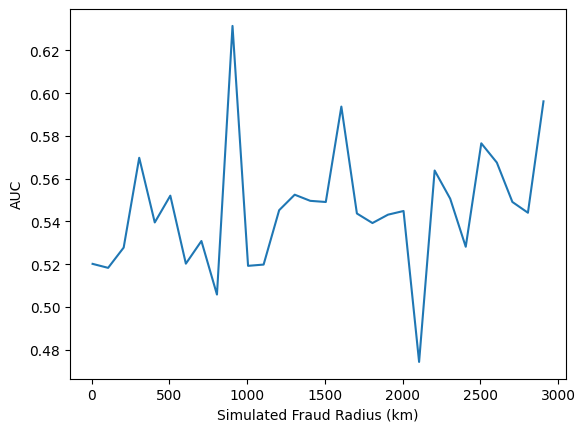

In [ ]:
#x = np.array([x['radius'] for x in res.rmse['per_radius_eval']])
#y = np.array([x['auc'] for x in res.rmse['per_radius_eval']])
x = np.array(list(res.auc_scores.keys()))
y = np.array(list(res.auc_scores.values()))
plt.plot(x, y, label='AUC')
if False:
    spl = UnivariateSpline(x, y, s=1)
    x_smooth = np.linspace(x.min(), x.max(), 500)
    y_smooth = spl(x_smooth)
    plt.plot(x_smooth, y_smooth, 'g-', lw=3, label='Smoothed')
plt.ylabel('AUC')
plt.xlabel('Simulated Fraud Radius (km)')

In [ ]:
res.rmse

{'mean_rmse': 1.1800431907236404,
 'var_rmse': 1.3382402919081664,
 'overall_rmse': 1.2591417413159034}

In [ ]:
from matplotlib import rc
rc('animation', html='jshtml')

means_isoscape = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=0)
raster.animate(means_isoscape,  1, 1)

In [ ]:
vars_isoscape = raster.load_raster(ISOSCAPE_SAVE_LOCATION, use_only_band_index=1)
raster.animate(vars_isoscape,  1, 1)